In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import os
import warnings

In [2]:
matches    = pd.read_csv("/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/matches.csv")
deliveries = pd.read_csv("/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/deliveries.csv")

In [3]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [4]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

# Cleaning Data & Handling Inconsistencies

In [5]:
print(matches['team1'].unique())

['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Rising Pune Supergiant' 'Delhi Capitals'
 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']


In [6]:
# Mapping for standardization
team_mappings = {
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Gujarat Lions' : 'Gujarat Titans',
    'Kings XI Punjab': 'Punjab Kings' # Though the name change was in 2021, some versions of the 2020 dataset use it
}

# Apply to matches
matches.replace(team_mappings, inplace=True)
# Apply to deliveries
deliveries.replace(team_mappings, inplace=True)

In [7]:
print(matches['venue'].unique())

['M Chinnaswamy Stadium' 'Punjab Cricket Association Stadium, Mohali'
 'Feroz Shah Kotla' 'Wankhede Stadium' 'Eden Gardens'
 'Sawai Mansingh Stadium' 'Rajiv Gandhi International Stadium, Uppal'
 'MA Chidambaram Stadium, Chepauk' 'Dr DY Patil Sports Academy' 'Newlands'
 "St George's Park" 'Kingsmead' 'SuperSport Park' 'Buffalo Park'
 'New Wanderers Stadium' 'De Beers Diamond Oval' 'OUTsurance Oval'
 'Brabourne Stadium' 'Sardar Patel Stadium, Motera' 'Barabati Stadium'
 'Brabourne Stadium, Mumbai'
 'Vidarbha Cricket Association Stadium, Jamtha'
 'Himachal Pradesh Cricket Association Stadium' 'Nehru Stadium'
 'Holkar Cricket Stadium'
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'
 'Subrata Roy Sahara Stadium' 'Maharashtra Cricket Association Stadium'
 'Shaheed Veer Narayan Singh International Stadium'
 'JSCA International Stadium Complex' 'Sheikh Zayed Stadium'
 'Sharjah Cricket Stadium' 'Dubai International Cricket Stadium'
 'Punjab Cricket Association IS Bindra Stadium, Mohali'


In [8]:
# 1. Remove extra commas and city names 
matches['venue'] = matches['venue'].str.split(',').str[0]

# 2. Define a dictionary for the specific discrepancies found
venue_mapping = {
    # Bangalore
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    
    # Mohali
    'Punjab Cricket Association IS Bindra Stadium': 'PCA IS Bindra Stadium',
    'Punjab Cricket Association Stadium': 'PCA IS Bindra Stadium',
    
    # Delhi
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    
    # Hyderabad
    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi Intl. Stadium',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi Intl. Stadium',
    
    # Chennai
    'MA Chidambaram Stadium': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    
    # Ahmedabad
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    
    # Pune
    'Subrata Roy Sahara Stadium': 'Maharashtra Cricket Association Stadium',
    
    # Abu Dhabi
    'Zayed Cricket Stadium': 'Sheikh Zayed Stadium'
}

# 3. Apply the mapping
matches['venue'] = matches['venue'].replace(venue_mapping)

# 4. Final strip to remove any trailing whitespace
matches['venue'] = matches['venue'].str.strip()

In [9]:
matches['venue'].unique()

array(['M Chinnaswamy Stadium', 'PCA IS Bindra Stadium',
       'Arun Jaitley Stadium', 'Wankhede Stadium', 'Eden Gardens',
       'Sawai Mansingh Stadium', 'Rajiv Gandhi Intl. Stadium',
       'MA Chidambaram Stadium', 'Dr DY Patil Sports Academy', 'Newlands',
       "St George's Park", 'Kingsmead', 'SuperSport Park', 'Buffalo Park',
       'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium', 'Sardar Patel Stadium',
       'Barabati Stadium', 'Vidarbha Cricket Association Stadium',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sheikh Zayed Stadium',
       'Sharjah Cricket Stadium', 'Dubai International Cricket Stadium',
       'Saurashtra Cricket Association Stadium', '

In [10]:
#Handling Missing Values
print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [11]:
#Find rows for which 'city' is null
null_city = matches[matches['city'].isnull()]
#null.city

In [12]:
# Fill missing city names based on venue
matches.loc[matches.venue == 'Dubai International Cricket Stadium', 'city'] = 'Dubai'
matches.loc[matches.venue == 'Sharjah Cricket Stadium', 'city'] = 'Sharjah'

In [13]:
null_winner = matches[matches['winner'].isnull()]
null_winner

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Arun Jaitley Stadium,Delhi Capitals,Pune Warriors,Delhi Capitals,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Delhi Capitals,Royal Challengers Bengaluru,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


In [14]:
# 1. Handling result_margin (Use 0 for matches with no margin)
matches['result_margin'] = matches['result_margin'].fillna(0)

# 2. Handling target_runs and target_overs
matches['target_runs'] = matches['target_runs'].fillna(0)
matches['target_overs'] = matches['target_overs'].fillna(0)

In [15]:
# 3. Handling categorical columns (These are strings, so 'No Result' is fine here)
matches['winner'] = matches['winner'].fillna('No Result')

In [16]:
matches['player_of_match'] = matches['player_of_match'].fillna('No Result')

In [17]:
matches['method'] = matches['method'].fillna('Standard')

In [18]:
# Final verification
print("Total Null Values Remaining:")
print(matches.isnull().sum().sum())

Total Null Values Remaining:
0


# Identify Discrepancies

If a match resulted in a "Tie" or "No Result," the result_margin should be 0. 

In [19]:
inconsistent_margins = matches[(matches['result'] == 'tie') & (matches['result_margin'] != 0)]
print(len(inconsistent_margins))

0


In [20]:
inconsistent_margins

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2


Check if any team name exists in team1 but not in winner (excluding "No Result"). This is to catch typos

In [21]:
all_teams = set(matches['team1'].unique()) | set(matches['team2'].unique())
winners = set(matches['winner'].unique())

# Teams that never won a single match (might be a typo)
print("Teams with 0 wins in the dataset:", all_teams - winners)

Teams with 0 wins in the dataset: set()


# Data Type Conversion & Datetime Parsing

In [22]:
# Convert to datetime
matches['date'] = pd.to_datetime(matches['date'])

# Extract features
matches['season'] = matches['date'].dt.year
matches['month'] = matches['date'].dt.month
matches['day_of_week'] = matches['date'].dt.day_name()

In [23]:
# Ensure numeric types on delivery columns
numeric_cols = ['is_wicket', 'batsman_runs', 'extra_runs', 'total_runs']

for col in numeric_cols:
    deliveries[col] = pd.to_numeric(deliveries[col], errors='coerce').fillna(0).astype(int)

# Ensure over and ball are integers
deliveries[['over', 'ball']] = deliveries[['over', 'ball']].astype(int)

In [24]:
# Standardize Player name
# List of columns containing player names
player_columns = ['batter', 'bowler', 'non_striker', 'player_dismissed', 'fielder']

for col in player_columns:
    deliveries[col] = deliveries[col].str.strip().str.title()

In [25]:
#Standardize team names
deliveries['batting_team'] = deliveries['batting_team'].replace(team_mappings)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_mappings)

print(deliveries['batting_team'].unique())

['Kolkata Knight Riders' 'Royal Challengers Bengaluru'
 'Chennai Super Kings' 'Punjab Kings' 'Rajasthan Royals' 'Delhi Capitals'
 'Mumbai Indians' 'Sunrisers Hyderabad' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Rising Pune Supergiant' 'Gujarat Titans'
 'Lucknow Super Giants']


In [26]:
# Handle Nulls in Categorical Delivery Columns
deliveries['extras_type'] = deliveries['extras_type'].fillna('None')
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('None')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('None')
deliveries['fielder'] = deliveries['fielder'].fillna('None')

In [27]:
# Ensuring numeric integrity
cols_to_fix = ['batsman_runs', 'extra_runs', 'total_runs', 'is_wicket']
deliveries[cols_to_fix] = deliveries[cols_to_fix].astype(int)

print(deliveries.dtypes)

match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batter              object
bowler              object
non_striker         object
batsman_runs         int64
extra_runs           int64
total_runs           int64
extras_type         object
is_wicket            int64
player_dismissed    object
dismissal_kind      object
fielder             object
dtype: object


In [28]:
# Check for any mathematical discrepancies
# Total runs should always be equal to batsman_runs and extra_runs
logic_check = deliveries[deliveries['total_runs'] != (deliveries['batsman_runs'] + deliveries['extra_runs'])]
print(f"Number of rows with run calculation errors: {len(logic_check)}")

# Validation of 'is_wicket'
# is_wicket should be 1 if player_dismissed is NOT 'None'
wicket_logic_check = deliveries[(deliveries['is_wicket'] == 1) & (deliveries['player_dismissed'] == 'None')]
print(f"Number of rows with missing dismissed player on a wicket: {len(wicket_logic_check)}")

Number of rows with run calculation errors: 0
Number of rows with missing dismissed player on a wicket: 0


In [29]:
# balls per over should typically be 1-6 excluding extras
print(f"Over range: {deliveries['over'].min()} to {deliveries['over'].max()}")
print(f"Ball range: {deliveries['ball'].min()} to {deliveries['ball'].max()}")

Over range: 0 to 19
Ball range: 1 to 11


# Feature Engineering

In [30]:
#Top 10 batsmen with highest strike rate
# Grouping by batter
batter_stats = deliveries.groupby('batter').agg({'batsman_runs': 'sum', 'ball': 'count'}).reset_index()
batter_stats.columns = ['batter', 'runs', 'balls_faced']

# Filter for minimum 500 balls faced
top_sr = batter_stats[batter_stats['balls_faced'] >= 500].copy()

# Calculate Strike Rate
top_sr['strike_rate'] = (top_sr['runs'] / top_sr['balls_faced']) * 100
top_sr = top_sr.sort_values(by='strike_rate', ascending=False).head(10)

top_sr

,batter,runs,balls_faced,strike_rate
44,Ad Russell,2488,1515,164.224422
208,H Klaasen,993,613,161.990212
581,Sp Narine,1534,984,155.894309
396,N Pooran,1769,1143,154.768154
325,Ls Livingstone,939,609,154.187192
203,Gj Maxwell,2772,1842,150.488599
490,Rm Patidar,799,534,149.625468
34,Abhishek Sharma,1377,925,148.864865
633,V Sehwag,2728,1833,148.827059
28,Ab De Villiers,5181,3487,148.580442


In [31]:
#Top 10 bowlers
# Grouping by bowler
bowler_stats = deliveries.groupby('bowler').agg({'total_runs': 'sum', 'ball': 'count'}).reset_index()
bowler_stats.columns = ['bowler', 'runs_conceded', 'balls_bowled']

# Filter for minimum 100 overs (600 balls)
top_econ = bowler_stats[bowler_stats['balls_bowled'] >= 600].copy()

# Calculate Economy (Runs per 6 balls)
top_econ['economy'] = (top_econ['runs_conceded'] / (top_econ['balls_bowled'] / 6))
top_econ = top_econ.sort_values(by='economy', ascending=True).head(10)

top_econ

,bowler,runs_conceded,balls_bowled,economy
7,A Kumble,1089,983,6.646999
264,M Muralitharan,1765,1581,6.698292
460,Sp Narine,4672,4146,6.761216
138,Dw Steyn,2583,2282,6.791411
130,Dl Vettori,894,785,6.833121
377,Rashid Khan,3340,2901,6.907963
176,J Botha,818,709,6.922426
355,R Ashwin,5435,4679,6.969438
291,Mm Ali,900,770,7.012987
451,Sl Malinga,3486,2974,7.032952


In [32]:
#Common dismissals
dismissal_counts = deliveries[deliveries['dismissal_kind'] != 'None']['dismissal_kind'].value_counts()
dismissal_counts

dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64

/tmp/ipykernel_17/791479638.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='winner', data=matches, order=order, palette='viridis', legend=False)


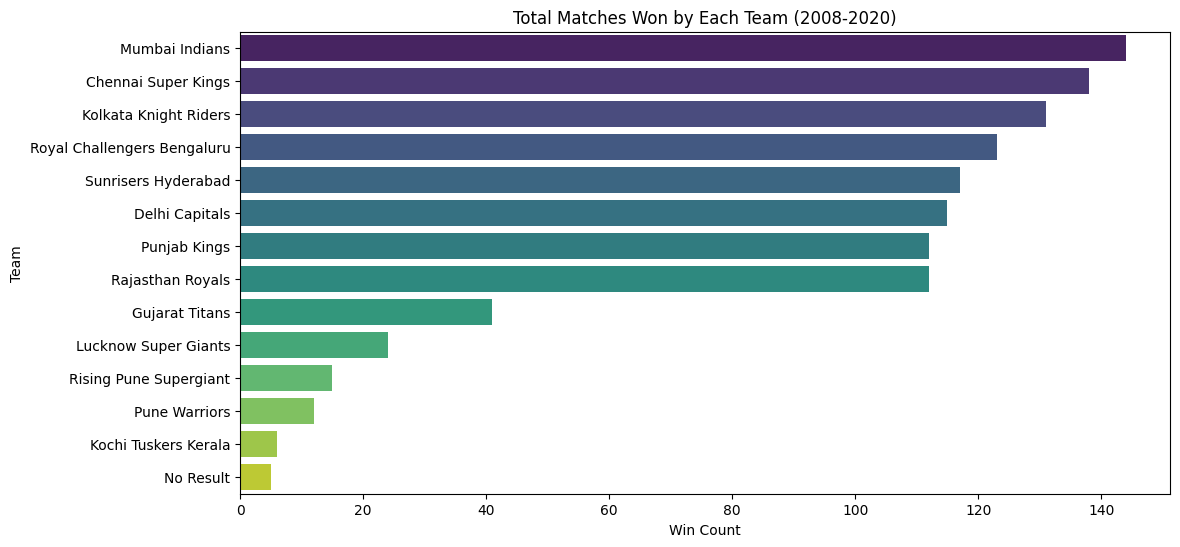

In [33]:
# Most successful teams
plt.figure(figsize=(12, 6))
order = matches['winner'].value_counts().index
sns.countplot(y='winner', data=matches, order=order, palette='viridis', legend=False)
plt.title('Total Matches Won by Each Team (2008-2020)')
plt.xlabel('Win Count')
plt.ylabel('Team')
plt.show()

/tmp/ipykernel_17/988104739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values, y=top_players.index, palette='mako')


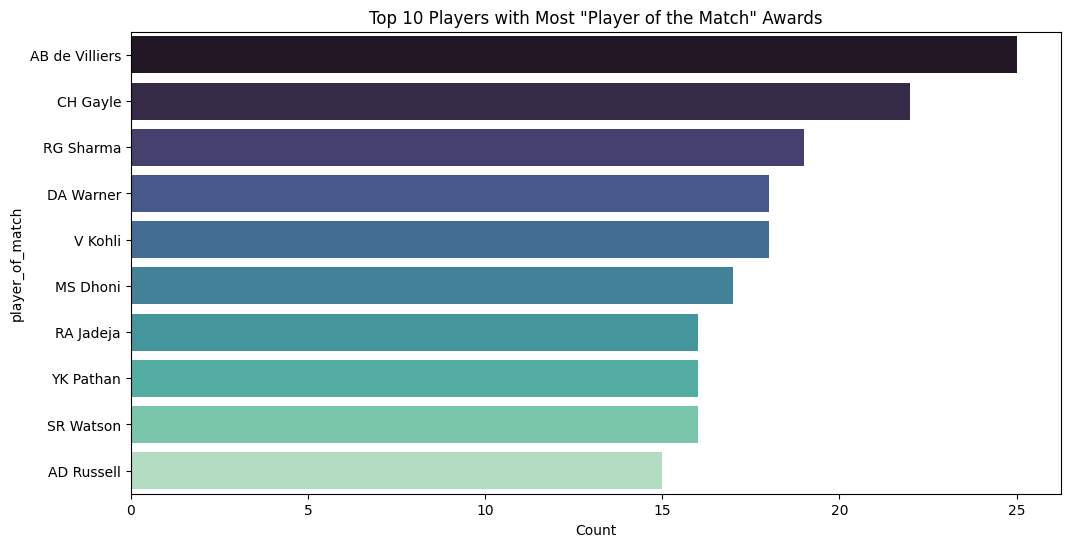

In [34]:
#Player of the match
top_players = matches['player_of_match'].value_counts()[:10]
plt.figure(figsize=(12, 6))
sns.barplot(x=top_players.values, y=top_players.index, palette='mako')
plt.title('Top 10 Players with Most "Player of the Match" Awards')
plt.xlabel('Count')
plt.show()

/tmp/ipykernel_17/4130616202.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='phase', y='total_runs', data=deliveries, estimator=sum, palette='viridis', order=['Powerplay', 'Middle', 'Death'])


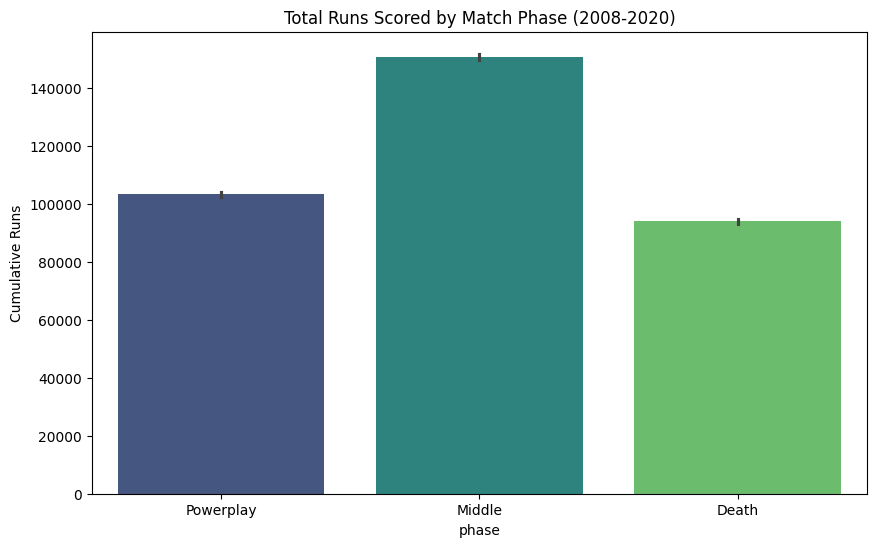

In [35]:
#Runs scored in different overs
# Define over phases
def get_phase(over):
    if over <= 5: return 'Powerplay'
    elif over <= 14: return 'Middle'
    else: return 'Death'

deliveries['phase'] = deliveries['over'].apply(get_phase)

# Plotting the distribution of runs by phase
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='phase', y='total_runs', data=deliveries, estimator=sum, palette='viridis', order=['Powerplay', 'Middle', 'Death'])
plt.title('Total Runs Scored by Match Phase (2008-2020)')
plt.ylabel('Cumulative Runs')
plt.show()

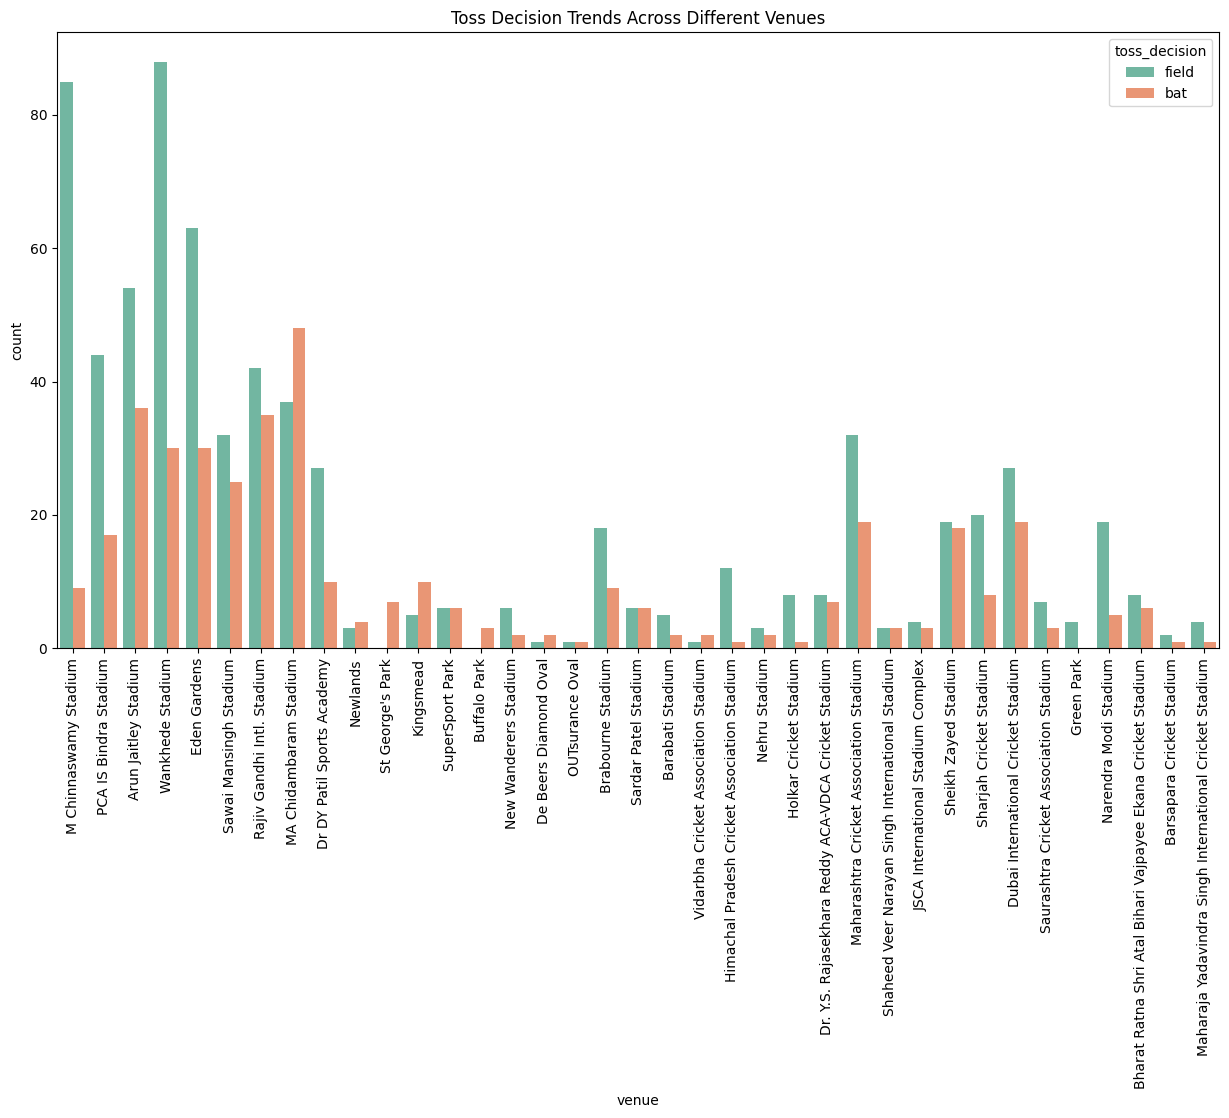

In [36]:
#Comparing batting first vs chasing target
plt.figure(figsize=(15, 8))
sns.countplot(x='venue', hue='toss_decision', data=matches, palette='Set2')
plt.xticks(rotation=90)
plt.title('Toss Decision Trends Across Different Venues')
plt.show()

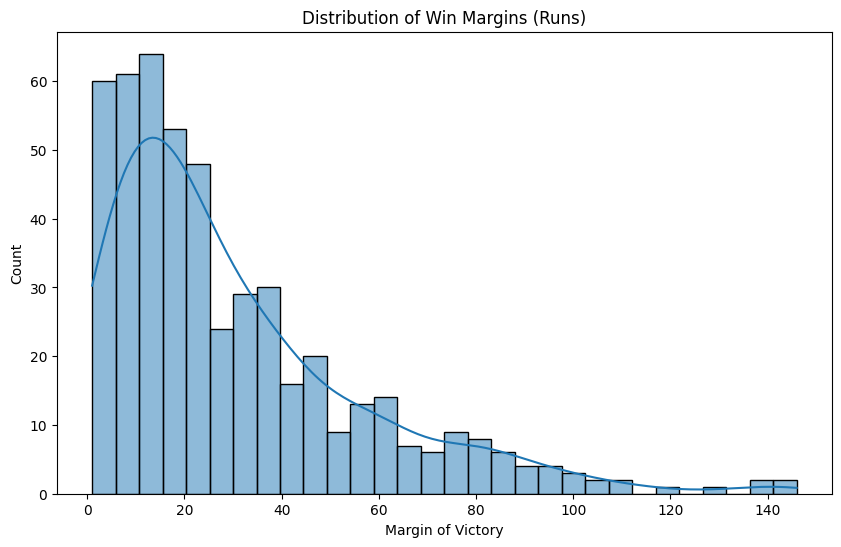

In [37]:
#win vs lose
plt.figure(figsize=(10, 6))
# Filter for runs (Batting first wins)
runs_margin = matches[matches['result'] == 'runs']['result_margin']
sns.histplot(runs_margin, kde=True, bins=30)
plt.title('Distribution of Win Margins (Runs)')
plt.xlabel('Margin of Victory')
plt.show()

/tmp/ipykernel_17/249971184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='toss_winner_is_winner', data=matches, palette='mako')


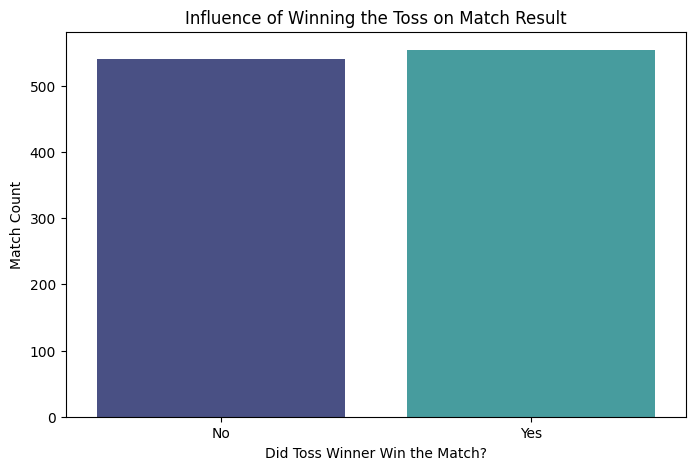

In [38]:
# Create a column for toss success
matches['toss_winner_is_winner'] = np.where(matches['toss_winner'] == matches['winner'], 'Yes', 'No')

plt.figure(figsize=(8, 5))
sns.countplot(x='toss_winner_is_winner', data=matches, palette='mako')
plt.title('Influence of Winning the Toss on Match Result')
plt.xlabel('Did Toss Winner Win the Match?')
plt.ylabel('Match Count')
plt.show()